# Scraping and Data Augmentation
This notebook scrapes supplementary weather data for Chicago and merges it with the crime dataset to enrich the analysis.

In [1]:
!pip install requests beautifulsoup4


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\meeka\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Step 1: Load the primary crime dataset
The primary dataset is the Chicago crime dataset used throughout the project.

In [3]:
crime_df = pd.read_csv("Chicago_Crimes_2012_to_2017.csv", nrows=50000)
crime_df["Date"] = pd.to_datetime(crime_df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
crime_df["date_only"] = crime_df["Date"].dt.date

crime_df.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,date_only
0,3,10508693,HZ250496,2016-05-03 23:40:00,013XX S SAWYER AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,1022,10.0,24.0,29.0,08B,1154907.0,1893681.0,2016,05/10/2016 03:56:50 PM,41.864073,-87.706819,"(41.864073157, -87.706818608)",2016-05-03
1,89,10508695,HZ250409,2016-05-03 21:40:00,061XX S DREXEL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,313,3.0,20.0,42.0,08B,1183066.0,1864330.0,2016,05/10/2016 03:56:50 PM,41.782922,-87.604363,"(41.782921527, -87.60436317)",2016-05-03
2,197,10508697,HZ250503,2016-05-03 23:31:00,053XX W CHICAGO AVE,0470,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,False,1524,15.0,37.0,25.0,24,1140789.0,1904819.0,2016,05/10/2016 03:56:50 PM,41.894908,-87.758372,"(41.894908283, -87.758371958)",2016-05-03
3,673,10508698,HZ250424,2016-05-03 22:10:00,049XX W FULTON ST,0460,BATTERY,SIMPLE,SIDEWALK,False,False,1532,15.0,28.0,25.0,08B,1143223.0,1901475.0,2016,05/10/2016 03:56:50 PM,41.885687,-87.749516,"(41.885686845, -87.749515983)",2016-05-03
4,911,10508699,HZ250455,2016-05-03 22:00:00,003XX N LOTUS AVE,0820,THEFT,$500 AND UNDER,RESIDENCE,False,True,1523,15.0,28.0,25.0,06,1139890.0,1901675.0,2016,05/10/2016 03:56:50 PM,41.886297,-87.761751,"(41.886297242, -87.761750709)",2016-05-03


## Step 2: Scrape supplementary weather data
Weather data is scraped to add external contextual features that may help explain temporal crime patterns.

In [4]:
url = "https://www.weather.gov/data/obhistory/KORD.html"

response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

table = soup.find("table")

rows = table.find_all("tr")

weather_data = []

for row in rows[1:]:
    cols = row.find_all("td")
    cols = [col.get_text(strip=True) for col in cols]
    
    if len(cols) >= 10:
        weather_data.append(cols)

weather_data[:5]

[['18',
  '12:51',
  'W\n        16\n        G 30',
  '10.00',
  'Partly Cloudy',
  'SCT034 SCT250',
  '48',
  '30',
  '48',
  '44.1',
  '50%',
  '42',
  '',
  '29.89',
  '1012.1',
  '',
  '',
  ''],
 ['18',
  '11:51',
  'W\n        17\n        G 25',
  '10.00',
  'Partly Cloudy',
  'SCT029 SCT250',
  '46',
  '30.9',
  '',
  '',
  '56%',
  '40',
  '',
  '29.87',
  '1011.6',
  '',
  '',
  ''],
 ['18',
  '10:51',
  'W\n        15\n        G 28',
  '10.00',
  'Mostly Cloudy',
  'SCT026 BKN250',
  '45',
  '32',
  '',
  '',
  '61%',
  '39',
  '',
  '29.86',
  '1011.1',
  '',
  '',
  ''],
 ['18',
  '09:51',
  'W\n        15\n        G 22',
  '10.00',
  'Mostly Cloudy',
  'FEW024 SCT120 SCT220 BKN250',
  '44.1',
  '33.1',
  '',
  '',
  '65%',
  '38',
  '',
  '29.82',
  '1009.7',
  '',
  '',
  ''],
 ['18',
  '08:51',
  'W\n        16\n        G 29',
  '10.00',
  'Overcast',
  'SCT024 SCT100 BKN210 OVC250',
  '45',
  '35.1',
  '',
  '',
  '68%',
  '38',
  '',
  '29.8',
  '1009.0',
  '',
  '',
 

In [5]:
weather_data[0]

['18',
 '12:51',
 'W\n        16\n        G 30',
 '10.00',
 'Partly Cloudy',
 'SCT034 SCT250',
 '48',
 '30',
 '48',
 '44.1',
 '50%',
 '42',
 '',
 '29.89',
 '1012.1',
 '',
 '',
 '']

In [6]:
[len(row) for row in weather_data[:5]]

[18, 18, 18, 18, 18]

In [7]:
weather_df = pd.DataFrame(weather_data)

weather_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,18,12:51,W\n 16\n G 30,10.00,Partly Cloudy,SCT034 SCT250,48,30,48,44.1,50%,42,,29.89,1012.1,,,
1,18,11:51,W\n 17\n G 25,10.00,Partly Cloudy,SCT029 SCT250,46,30.9,,,56%,40,,29.87,1011.6,,,
2,18,10:51,W\n 15\n G 28,10.00,Mostly Cloudy,SCT026 BKN250,45,32,,,61%,39,,29.86,1011.1,,,
3,18,09:51,W\n 15\n G 22,10.00,Mostly Cloudy,FEW024 SCT120 SCT220 BKN250,44.1,33.1,,,65%,38,,29.82,1009.7,,,
4,18,08:51,W\n 16\n G 29,10.00,Overcast,SCT024 SCT100 BKN210 OVC250,45,35.1,,,68%,38,,29.8,1009.0,,,


In [8]:
weather_df.iloc[0]

0                              18
1                           12:51
2     W\n        16\n        G 30
3                           10.00
4                   Partly Cloudy
5                   SCT034 SCT250
6                              48
7                              30
8                              48
9                            44.1
10                            50%
11                             42
12                               
13                          29.89
14                         1012.1
15                               
16                               
17                               
Name: 0, dtype: str

In [9]:
weather_clean = pd.DataFrame({
    "Day": weather_df[0],
    "Time": weather_df[1],
    "Wind": weather_df[2],
    "Visibility": weather_df[3],
    "Weather": weather_df[4],
    "Sky_Cond": weather_df[5],
    "Temp_F": weather_df[6],
    "Humidity": weather_df[10],
    "Pressure_in": weather_df[13],
    "Pressure_mbar": weather_df[14]
})

weather_clean.head()

,Day,Time,Wind,Visibility,Weather,Sky_Cond,Temp_F,Humidity,Pressure_in,Pressure_mbar
0,18,12:51,W\n 16\n G 30,10.00,Partly Cloudy,SCT034 SCT250,48,50%,29.89,1012.1
1,18,11:51,W\n 17\n G 25,10.00,Partly Cloudy,SCT029 SCT250,46,56%,29.87,1011.6
2,18,10:51,W\n 15\n G 28,10.00,Mostly Cloudy,SCT026 BKN250,45,61%,29.86,1011.1
3,18,09:51,W\n 15\n G 22,10.00,Mostly Cloudy,FEW024 SCT120 SCT220 BKN250,44.1,65%,29.82,1009.7
4,18,08:51,W\n 16\n G 29,10.00,Overcast,SCT024 SCT100 BKN210 OVC250,45,68%,29.8,1009.0


In [10]:
weather_clean["Temp_F"] = pd.to_numeric(weather_clean["Temp_F"], errors="coerce")
weather_clean["Humidity_pct"] = pd.to_numeric(
    weather_clean["Humidity"].astype(str).str.replace("%", "", regex=False),
    errors="coerce"
)
weather_clean["Pressure_in"] = pd.to_numeric(weather_clean["Pressure_in"], errors="coerce")
weather_clean["Pressure_mbar"] = pd.to_numeric(weather_clean["Pressure_mbar"], errors="coerce")
weather_clean["Visibility_mi"] = pd.to_numeric(weather_clean["Visibility"], errors="coerce")

weather_clean.head()

,Day,Time,Wind,Visibility,Weather,Sky_Cond,Temp_F,Humidity,Pressure_in,Pressure_mbar,Humidity_pct,Visibility_mi
0,18,12:51,W\n 16\n G 30,10.00,Partly Cloudy,SCT034 SCT250,48.0,50%,29.89,1012.1,50,10.0
1,18,11:51,W\n 17\n G 25,10.00,Partly Cloudy,SCT029 SCT250,46.0,56%,29.87,1011.6,56,10.0
2,18,10:51,W\n 15\n G 28,10.00,Mostly Cloudy,SCT026 BKN250,45.0,61%,29.86,1011.1,61,10.0
3,18,09:51,W\n 15\n G 22,10.00,Mostly Cloudy,FEW024 SCT120 SCT220 BKN250,44.1,65%,29.82,1009.7,65,10.0
4,18,08:51,W\n 16\n G 29,10.00,Overcast,SCT024 SCT100 BKN210 OVC250,45.0,68%,29.80,1009.0,68,10.0


In [11]:
weather_clean["Temp_C"] = (weather_clean["Temp_F"] - 32) * 5/9

In [12]:
weather_clean["date_only"] = pd.to_datetime("2026-04-18").date()

## Step 3: Create a daily weather summary
The scraped weather records are hourly observations. To make them compatible with the crime dataset, they are aggregated to daily level using the mean of temperature, humidity, pressure, and visibility.

In [13]:
weather_daily = weather_clean.groupby("date_only").agg({
    "Temp_C": "mean",
    "Humidity_pct": "mean",
    "Pressure_mbar": "mean",
    "Visibility_mi": "mean"
}).reset_index()

weather_daily

,date_only,Temp_C,Humidity_pct,Pressure_mbar,Visibility_mi
0,2026-04-18,16.705247,77.708333,1008.265278,8.458472


In [14]:
merged_df = crime_df.merge(weather_daily, on="date_only", how="left")

merged_df.head()

,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,date_only,Temp_C,Humidity_pct,Pressure_mbar,Visibility_mi
0,3,10508693,HZ250496,2016-05-03 23:40:00,013XX S SAWYER AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,1022,10.0,24.0,29.0,08B,1154907.0,1893681.0,2016,05/10/2016 03:56:50 PM,41.864073,-87.706819,"(41.864073157, -87.706818608)",2016-05-03,NaN,NaN,NaN,NaN
1,89,10508695,HZ250409,2016-05-03 21:40:00,061XX S DREXEL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,313,3.0,20.0,42.0,08B,1183066.0,1864330.0,2016,05/10/2016 03:56:50 PM,41.782922,-87.604363,"(41.782921527, -87.60436317)",2016-05-03,NaN,NaN,NaN,NaN
2,197,10508697,HZ250503,2016-05-03 23:31:00,053XX W CHICAGO AVE,0470,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,False,1524,15.0,37.0,25.0,24,1140789.0,1904819.0,2016,05/10/2016 03:56:50 PM,41.894908,-87.758372,"(41.894908283, -87.758371958)",2016-05-03,NaN,NaN,NaN,NaN
3,673,10508698,HZ250424,2016-05-03 22:10:00,049XX W FULTON ST,0460,BATTERY,SIMPLE,SIDEWALK,False,False,1532,15.0,28.0,25.0,08B,1143223.0,1901475.0,2016,05/10/2016 03:56:50 PM,41.885687,-87.749516,"(41.885686845, -87.749515983)",2016-05-03,NaN,NaN,NaN,NaN
4,911,10508699,HZ250455,2016-05-03 22:00:00,003XX N LOTUS AVE,0820,THEFT,$500 AND UNDER,RESIDENCE,False,True,1523,15.0,28.0,25.0,06,1139890.0,1901675.0,2016,05/10/2016 03:56:50 PM,41.886297,-87.761751,"(41.886297242, -87.761750709)",2016-05-03,NaN,NaN,NaN,NaN


## Step 4: Merge strategy and limitations
The weather data was merged with the crime dataset using the `date_only` field and a left join to preserve all crime records. Because the scraped weather table only covers a recent day, weather values are available only for matching dates. This notebook therefore demonstrates the augmentation workflow and merge strategy rather than a full historical weather enrichment.

In [15]:
matched_weather_rows = merged_df[merged_df["Temp_C"].notna()]

print("Rows with matched weather data:", matched_weather_rows.shape[0])
print("Available columns:", list(merged_df.columns))

if matched_weather_rows.shape[0] > 0:
    display(matched_weather_rows.head())
else:
    print("No matched rows were found because the scraped weather dates do not overlap with the crime dataset sample.")

Rows with matched weather data: 0
Available columns: ['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location', 'date_only', 'Temp_C', 'Humidity_pct', 'Pressure_mbar', 'Visibility_mi']
No matched rows were found because the scraped weather dates do not overlap with the crime dataset sample.


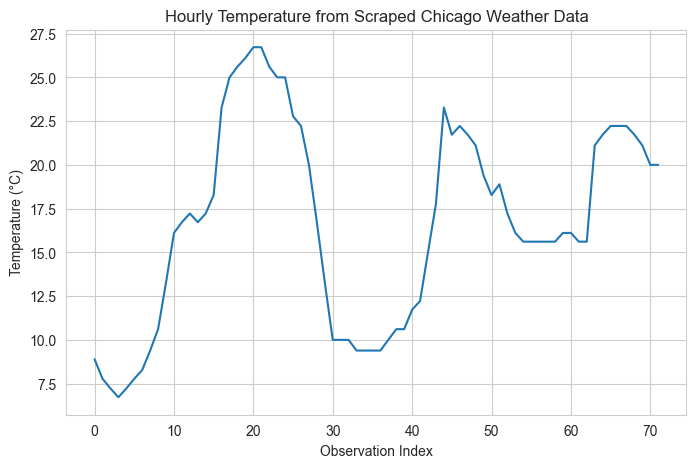

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(weather_clean["Temp_C"].reset_index(drop=True))
plt.title("Hourly Temperature from Scraped Chicago Weather Data")
plt.xlabel("Observation Index")
plt.ylabel("Temperature (°C)")
plt.show()

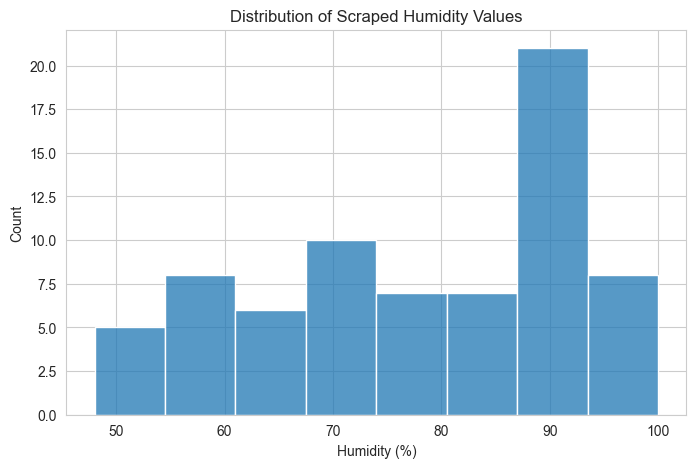

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(weather_clean["Humidity_pct"], bins=8)
plt.title("Distribution of Scraped Humidity Values")
plt.xlabel("Humidity (%)")
plt.ylabel("Count")
plt.show()

## Step 5: Key observations
The scraped supplementary dataset provides external environmental context for Chicago. Although the merge is only demonstrated on matching dates, the workflow shows how weather variables such as temperature, humidity, pressure, and visibility can be integrated with crime records to support richer analysis.

## Scraping methodology
The supplementary weather data was scraped from the NOAA weather history page using the `requests` library to retrieve the page and `BeautifulSoup` to parse the HTML table. The relevant observation table was extracted and converted into a structured dataframe. Numeric values such as temperature, humidity, pressure, and visibility were cleaned and aggregated to daily level before merging with the crime dataset.

## AI usage note
AI was used to suggest the scraping workflow, debugging steps, and notebook structure. The final code was executed, tested, and validated by the student.